# Description

Project about customer churn telecom operator form Bulgarian, which contain business cutomers, small, medium, and large companies

Dataset: [https://data.mendeley.com/datasets/nrb55gr66h/1](https://data.mendeley.com/datasets/nrb55gr66h/1)

In [1]:
# Library

import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data Understanding

In [2]:
df_churn_raw = pd.read_csv("E:\Platinum\Important\Project\Costumer-Churn-Project\Dataset\Baza customer Telecom v2.csv")

# Make Copy
df_churn = df_churn_raw.copy()
df_churn.head()

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No


## Data Description

- PID: Unique identifier for each customer account.

- CRM_PID_Value_Segment: Customer value segment assigned by the CRM system (e.g., Bronze, Silver, Gold, Iron). Indicates the business value or importance of the customer.

- EffectiveSegment: Business segment classification of the customer such as SOHO (Small Office Home Office), SME, or enterprise-level companies.

- Billing_ZIP: Postal code of the customer’s billing address. Represents the geographic location of the customer.

- KA_name: Key Account manager or internal business unit responsible for managing the customer account.

- Active_subscribers: Number of currently active subscribers associated with the customer account.

- Not_Active_subscribers: Number of subscribers that are currently inactive but still registered under the account.

- Suspended_subscribers: Number of subscribers temporarily suspended by the operator.

- Total_SUBs: Total number of subscribers linked to the customer account.

- AvgMobileRevenue: Average revenue generated from mobile services for the customer.

- AvgFIXRevenue: Average revenue generated from fixed-line services.

- TotalRevenue: Total revenue generated from the customer account.

- ARPU: Average Revenue Per User. Calculated as total revenue divided by total subscribers.

- CHURN: Target variable indicating whether the customer has churned (Yes) or remained active (No).

In [3]:
print("Dataset Info:")
df_churn.info()
print(" ")
print("Dataset Stats: ")
df_churn.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8452 non-null   float64
 13  CHURN                   8453 non-null   object 
dtypes: float64(7), int64(2), o

,Billing_ZIP,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU
count,8451.000000,8453.000000,4304.000000,352.000000,8453.000000,8453.000000,8453.000000,8453.000000,8452.000000
mean,4879.727725,7.774636,4.163336,1.576705,9.960132,148.011956,0.821185,148.833141,24.441789
std,1061.095394,6.680524,9.462847,1.979905,10.246648,102.570539,11.737880,103.250779,22.820585
min,1000.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.670000,0.000000
25%,4003.000000,4.000000,1.000000,1.000000,5.000000,71.500000,0.000000,71.830000,14.070000
50%,4400.000000,6.000000,2.000000,1.000000,7.000000,113.170000,0.000000,113.670000,19.315000
75%,6000.000000,10.000000,4.000000,1.000000,12.000000,191.170000,0.000000,192.330000,27.255000
max,9644.000000,110.000000,214.000000,22.000000,235.000000,499.830000,480.500000,499.830000,462.830000


# Data Cleaning

In [4]:
# Checking Missing Value
print("Missing Value: ")
missing_count = df_churn.isnull().sum()
missing_percent = (missing_count / len(df_churn)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table = missing_table.sort_values("Missing %", ascending=False)

print(missing_table)

# Checking Duplicate Data
print("\nDuplicate Data:")

duplicates = df_churn.duplicated().sum()

if duplicates == 0:
    print("No duplicate data")
else:
    print(f"Found {duplicates} duplicate rows")

Missing Value: 
                        Missing Count  Missing %
Suspended_subscribers            8101  95.835798
Not_Active_subscribers           4149  49.083166
CRM_PID_Value_Segment               5   0.059151
Billing_ZIP                         2   0.023660
ARPU                                1   0.011830

Duplicate Data:
No duplicate data


In [5]:
# Drop column with extreme missing
df_churn.drop(columns=['Suspended_subscribers'], inplace=True)

# Fill numeric missing
df_churn['Not_Active_subscribers'] = df_churn['Not_Active_subscribers'].fillna(0)

# Fill categorical missing
df_churn['CRM_PID_Value_Segment'] = df_churn['CRM_PID_Value_Segment'].fillna(
    df_churn['CRM_PID_Value_Segment'].mode()[0]
)

# Fill ZIP code
df_churn['Billing_ZIP'] = df_churn['Billing_ZIP'].fillna(
    df_churn['Billing_ZIP'].mode()[0]
)

# Fill ARPU with calculation
df_churn['ARPU'] = df_churn['ARPU'].fillna(
    df_churn['TotalRevenue'] / df_churn['Total_SUBs']
)

In [6]:
# Checking Missing Value Again
print("Missing Value (%):")
missing = (df_churn.isnull().sum() / len(df_churn)) * 100
print(missing[missing > 0].sort_values(ascending=False))

Missing Value (%):
Series([], dtype: float64)


# EDA

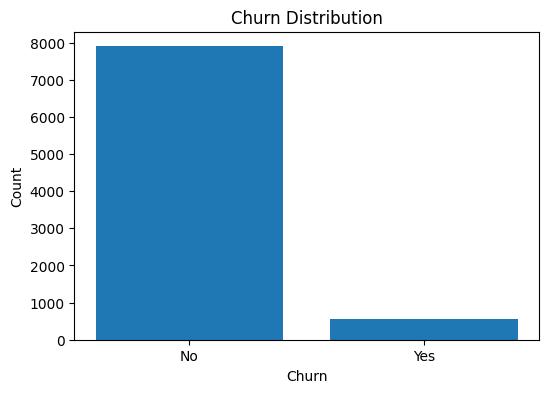

In [7]:
churn_counts = df_churn['CHURN'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

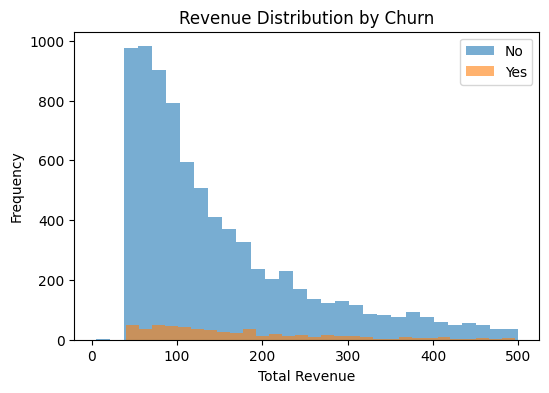

In [8]:
churn_yes = df_churn[df_churn['CHURN']=='Yes']['TotalRevenue']
churn_no = df_churn[df_churn['CHURN']=='No']['TotalRevenue']

plt.figure(figsize=(6,4))

plt.hist(churn_no, bins=30, alpha=0.6, label='No')
plt.hist(churn_yes, bins=30, alpha=0.6, label='Yes')

plt.title("Revenue Distribution by Churn")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.legend()

plt.show()

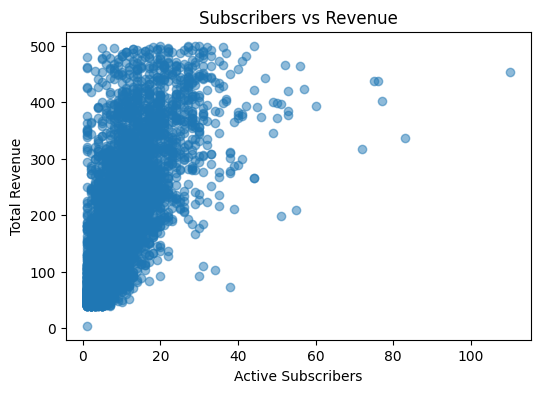

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(df_churn['Active_subscribers'], df_churn['TotalRevenue'], 
            alpha=0.5)

plt.xlabel("Active Subscribers")
plt.ylabel("Total Revenue")
plt.title("Subscribers vs Revenue")

plt.show()

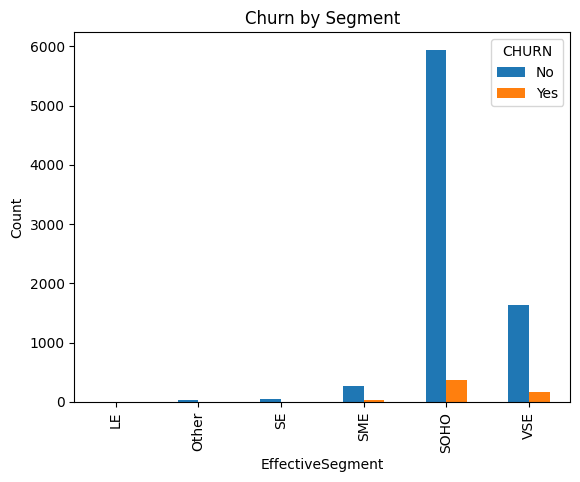

In [10]:
segment_churn = df_churn.groupby('EffectiveSegment')['CHURN'].value_counts().unstack()

segment_churn.plot(kind='bar')

plt.title("Churn by Segment")
plt.ylabel("Count")
plt.show()

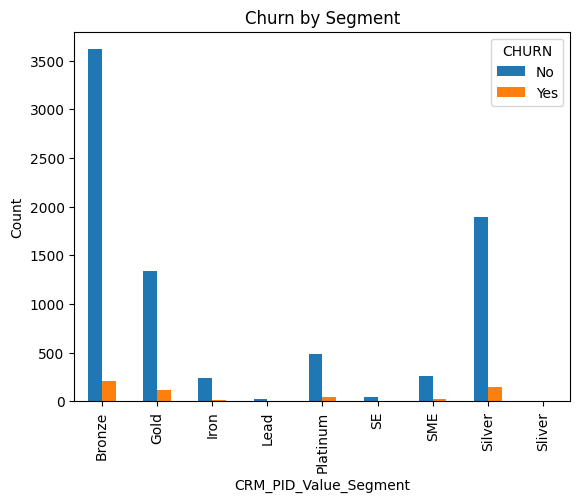

In [ ]:
segment_churn = df_churn.groupby('CRM_PID_Value_Segment')['CHURN'].value_counts().unstack()

segment_churn.plot(kind='bar')

plt.title("Churn by Segment")
plt.ylabel("Count")
plt.show()